## 1. Read the dataset and display some information about the dataset. [ Score: 1 point ]

### Import required libraries and read the dataset.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt   
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# splitting, scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# evaluation metrics
from sklearn import metrics
from sklearn.metrics import recall_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Package for handling imbalance data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Pipeline and transformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

!pip install mlxtend
import joblib
import sys
sys.modules['sklearn.externals.joblib'] = joblib
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# To view all the columns
pd.set_option('display.max_columns', None)

### Check the first few samples, shape, info of the data and try to familiarize yourself with different features.

In [2]:
## Read and check first few samples

df = pd.read_csv('download-2.csv')
df.head()

,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,65087372,10000,32236,12329.36286,59,BAT2522922,11.135007,B,C4,MORTGAGE,176346.62670,Not Verified,n,Debt Consolidation,16.284758,1,0,13,0,24246,74.932551,7,w,2929.646315,0.102055,2.498291,0.793724,0,INDIVIDUAL,49,0,31,311301,6619,0
1,1450153,3609,11940,12191.99692,59,BAT1586599,12.237563,C,D3,RENT,39833.92100,Source Verified,n,Debt consolidation,15.412409,0,0,12,0,812,78.297186,13,f,772.769385,0.036181,2.377215,0.974821,0,INDIVIDUAL,109,0,53,182610,20885,0
2,1969101,28276,9311,21603.22455,59,BAT2136391,12.545884,F,D4,MORTGAGE,91506.69105,Source Verified,n,Debt Consolidation,28.137619,0,0,14,0,1843,2.073040,20,w,863.324396,18.778660,4.316277,1.020075,0,INDIVIDUAL,66,0,34,89801,26155,0
3,6651430,11170,6954,17877.15585,59,BAT2428731,16.731201,C,C3,MORTGAGE,108286.57590,Source Verified,n,Debt consolidation,18.043730,1,0,7,0,13819,67.467951,12,w,288.173196,0.044131,0.107020,0.749971,0,INDIVIDUAL,39,0,40,9189,60214,0
4,14354669,16890,13226,13539.92667,59,BAT5341619,15.008300,C,D4,MORTGAGE,44234.82545,Source Verified,n,Credit card refinancing,17.209886,1,3,13,1,1544,85.250761,22,w,129.239553,19.306646,1294.818751,0.368953,0,INDIVIDUAL,18,0,430,126029,22579,0


In [3]:
## Lets check basic information of the dataset.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67463 entries, 0 to 67462
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            67463 non-null  int64  
 1   Loan Amount                   67463 non-null  int64  
 2   Funded Amount                 67463 non-null  int64  
 3   Funded Amount Investor        67463 non-null  float64
 4   Term                          67463 non-null  int64  
 5   Batch Enrolled                67463 non-null  object 
 6   Interest Rate                 67463 non-null  float64
 7   Grade                         67463 non-null  object 
 8   Sub Grade                     67463 non-null  object 
 9   Employment Duration           67463 non-null  object 
 10  Home Ownership                67463 non-null  float64
 11  Verification Status           67463 non-null  object 
 12  Payment Plan                  67463 non-null  object 
 13  L

In [4]:
df.shape

(67463, 35)

In [5]:
# List of object type features

list(df.select_dtypes(['object']).columns)

['Batch Enrolled',
 'Grade',
 'Sub Grade',
 'Employment Duration',
 'Verification Status',
 'Payment Plan',
 'Loan Title',
 'Initial List Status',
 'Application Type']

In [6]:
# All features of the dataframe with their unique values.

for col in df.columns:
    print(col, df[col].nunique())

ID 67463
Loan Amount 27525
Funded Amount 24548
Funded Amount Investor 67441
Term 3
Batch Enrolled 41
Interest Rate 67448
Grade 7
Sub Grade 35
Employment Duration 3
Home Ownership 67454
Verification Status 3
Payment Plan 1
Loan Title 109
Debit to Income 67454
Delinquency - two years 9
Inquires - six months 6
Open Account 36
Public Record 5
Revolving Balance 20582
Revolving Utilities 67458
Total Accounts 69
Initial List Status 2
Total Received Interest 67451
Total Received Late Fee 67380
Recoveries 67387
Collection Recovery Fee 67313
Collection 12 months Medical 2
Application Type 2
Last week Pay 162
Accounts Delinquent 1
Total Collection Amount 2193
Total Current Balance 60901
Total Revolving Credit Limit 37708
Loan Status 2


### Different classes of category type columns in the dataframe:

In [7]:
# Grades of different customers issued by the banks

df['Grade'].unique()

array(['B', 'C', 'F', 'A', 'G', 'E', 'D'], dtype=object)

In [8]:
# It seems that the name given to the column 'Employment Duration' is not correct.
# 'Employment Duration' should be in years whereas it consists of classes 'MORTGAGE', 'RENT', 'OWN'. ???

df['Employment Duration'].unique()

array(['MORTGAGE', 'RENT', 'OWN'], dtype=object)

In [9]:
df['Verification Status'].unique()

array(['Not Verified', 'Source Verified', 'Verified'], dtype=object)

In [10]:
df['Payment Plan'].unique()

array(['n'], dtype=object)

In [11]:
# No account is delinquent

df['Accounts Delinquent'].unique()

array([0])

In [12]:
#  different number of loan Titles.

df['Loan Title'].nunique()

109

In [13]:
# 'w'= Waiting, 'f'= Forwarded

df['Initial List Status'].unique()

array(['w', 'f'], dtype=object)

In [14]:
# Loan application type of customers

df['Application Type'].unique()

array(['INDIVIDUAL', 'JOINT'], dtype=object)

## 2. Data cleansing and Exploratory data analysis

### Check if there are any duplicate records in the dataset? if any drop them.

In [15]:
len(df[df.duplicated()])

0

### Check the percentage of missing values, if any? treat them with appropriate methods.

In [16]:
## Let us check for the percentage of missing values.

df.isnull().sum()/len(df)*100

ID                              0.0
Loan Amount                     0.0
Funded Amount                   0.0
Funded Amount Investor          0.0
Term                            0.0
Batch Enrolled                  0.0
Interest Rate                   0.0
Grade                           0.0
Sub Grade                       0.0
Employment Duration             0.0
Home Ownership                  0.0
Verification Status             0.0
Payment Plan                    0.0
Loan Title                      0.0
Debit to Income                 0.0
Delinquency - two years         0.0
Inquires - six months           0.0
Open Account                    0.0
Public Record                   0.0
Revolving Balance               0.0
Revolving Utilities             0.0
Total Accounts                  0.0
Initial List Status             0.0
Total Received Interest         0.0
Total Received Late Fee         0.0
Recoveries                      0.0
Collection Recovery Fee         0.0
Collection 12 months Medical

### Check summary statistics of the dataset, and write your key observations.

In [17]:
# Summary statistics for numerical columns

df.describe().T 

,count,mean,std,min,25%,50%,75%,max
ID,67463.0,2.562761e+07,2.109155e+07,1.297933e+06,6.570288e+06,1.791565e+07,4.271521e+07,7.224578e+07
Loan Amount,67463.0,1.684890e+04,8.367866e+03,1.014000e+03,1.001200e+04,1.607300e+04,2.210600e+04,3.500000e+04
Funded Amount,67463.0,1.577060e+04,8.150993e+03,1.014000e+03,9.266500e+03,1.304200e+04,2.179300e+04,3.499900e+04
Funded Amount Investor,67463.0,1.462180e+04,6.785345e+03,1.114590e+03,9.831685e+03,1.279368e+04,1.780759e+04,3.499975e+04
Term,67463.0,5.817381e+01,3.327441e+00,3.600000e+01,5.800000e+01,5.900000e+01,5.900000e+01,5.900000e+01
Interest Rate,67463.0,1.184626e+01,3.718629e+00,5.320006e+00,9.297147e+00,1.137770e+01,1.419353e+01,2.718235e+01
Home Ownership,67463.0,8.054150e+04,4.502912e+04,1.457354e+04,5.168984e+04,6.933583e+04,9.462332e+04,4.065615e+05
Debit to Income,67463.0,2.329924e+01,8.451824e+00,6.752991e-01,1.675642e+01,2.265666e+01,3.004840e+01,3.962986e+01
Delinquency - two years,67463.0,3.271275e-01,8.008884e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00
Inquires - six months,67463.0,1.457540e-01,4.732913e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00


- The maximum applied loan amount is 35000 dollars and minimum is 1014 dollars.
- The maximum term of loan is 59 and minimum is 36 months.
- The average term of loan is almost 58 months.
- The maximum Interest rate of the loan is 27% and min is 5.3%.
- The average Total received interest is around 2068 dollars.
- The maximum Total received late fee charges is around 42 dollars.
- 'Accounts Delinquent' has 0 variance, so may be dropped for analysis

In [18]:
# summary for categorical columns

df.describe(include='O').T 

,count,unique,top,freq
Batch Enrolled,67463,41,BAT3873588,3626
Grade,67463,7,C,19085
Sub Grade,67463,35,B4,4462
Employment Duration,67463,3,MORTGAGE,36351
Verification Status,67463,3,Source Verified,33036
Payment Plan,67463,1,n,67463
Loan Title,67463,109,Credit card refinancing,30728
Initial List Status,67463,2,w,36299
Application Type,67463,2,INDIVIDUAL,67340


- Employment Duration, Verification Status features has 3 unique categories.
- Initial List status, Application Type has 2 unique categories, w(Waiting) status has a frequecy of 36299.
- Batch Enrolled has 41,Subgrade has 35, Loan Title has 109 unique categories.
- These features need to be dropped, since these have many subcategories, also redundant for our analyis

### Drop the columns which you think redundant for the analysis.

In [19]:
# Since 'ID' is only customer identifier. 
# 'Accounts Delinquent' has constant variance.
# 'Payment Plan' contains a single unique value for all observations; so We drop these three features
 
df.drop(['ID','Accounts Delinquent','Payment Plan'],axis=1, inplace=True)

### Perform necessary univariate and multivariate analysis

Text(0.5, 0, 'Interest Rate')

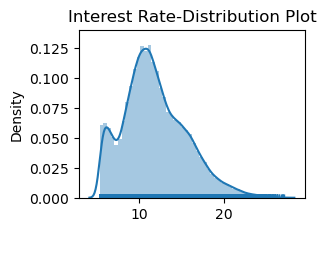

In [20]:
plt.subplot(2,2,1)
ax=sns.distplot(df['Interest Rate'],rug=True)
ax.set(title='Interest Rate-Distribution Plot')
ax.set_xlabel('Interest Rate',fontsize=14,color='w')

- There are two peaks one almost for interst rate of ~5% and the other for ~10% 
- Most of the area under the curve lies between 10%-20%
- It implies that most of the bank loans are in the interest rates between 10%-20%.

Text(0, 0.5, 'Interest Rate')

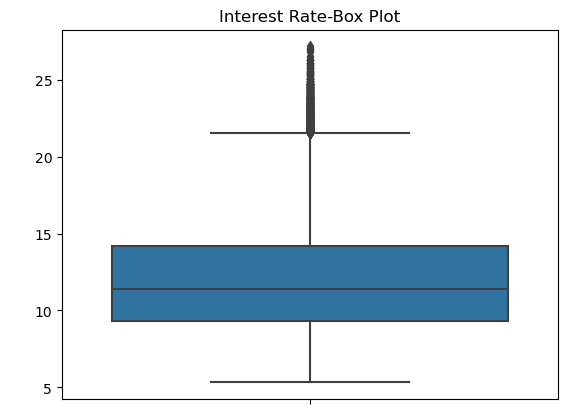

In [21]:
ax=sns.boxplot(y=df['Interest Rate'])
ax.set(title='Interest Rate-Box Plot')
ax.set_ylabel('Interest Rate',fontsize=14,color='w')

- There are outliers beyond certain rate of interest > ~21%, which is infact very high rate of interest

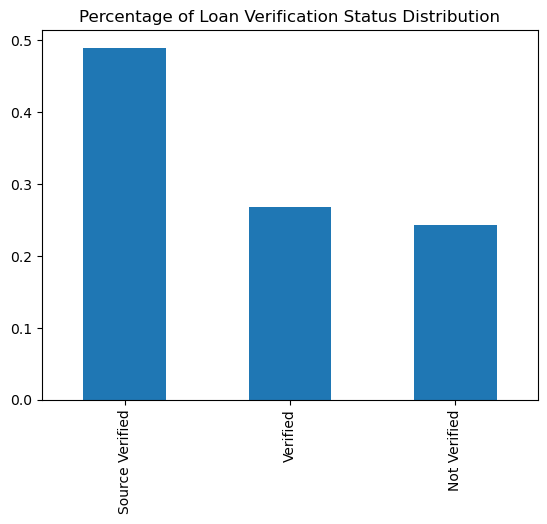

In [22]:
# Distibution for Verification Status

df['Verification Status'].value_counts(normalize=True).plot.bar()
plt.title("Percentage of Loan Verification Status Distribution")
plt.show()

- Most of the loans are source verified, followed by those which are verified
- Almost 20% of loan cases are not verified

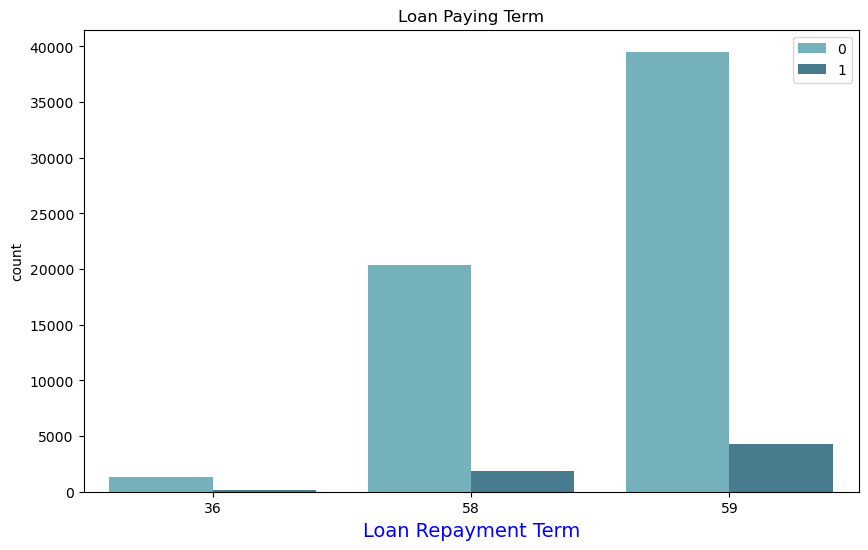

In [23]:
plt.figure(figsize=(10,6),facecolor='w')
ax=sns.countplot(x="Term",data=df,hue='Loan Status',palette='GnBu_d')
ax.set(title='Loan Paying Term')
ax.set_xlabel('Loan Repayment Term',fontsize=14,color = 'b')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

- 1 = Defaulter, 0 = Non Defaulters
- Loan cases where term of the loan is 59 months has most of cases as non-defaulters
- It is evident that bank/customers prefer loan for longer term
- However the list of defaulter cases is small in each term of loan, but is the highest for term of 59 months
- The term of 36 months is least preffered
- But there also is a sleek line of defaulters in case of term of 36 months. 

- The first three diagonal kde plots are having multiple peaks means that the data correspond to the attribute is of multiple classes of the attribute
- There are two instances 6 times and 7 times of 'Delinquency-2 Years' where the term of loan 'Term' is 36 months
- 'Loan Amount' to 'Funded Amount' and 'Funded Amount Invester' show no particular trend as the data is mixed.
- The fourth diagonal kde plot corresponds to 'Term' shows 3 peaks
- (one very small, the other two larger, but the last one the longest) 
- correspond respectively to 36, 58 and 59 months.
- For 6 inquiries conducted by the bank during last 6 months  on  terms (36,58,59), no instances of
- defaulters were reported for term of 58 and 59 months but there were 2 instances of defaulters in 5 total inquiries on a term of 36 months
- Collection Recovery Fee shows a single instance of a fee of more than $150 must be an outlier.

### Check the distribution of the target column 'Loan Status', and comment on the class distribution

In [26]:
# distribution of the target column 'Loan Status' before resampling

df['Loan Status'].value_counts()

0    61222
1     6241
Name: Loan Status, dtype: int64

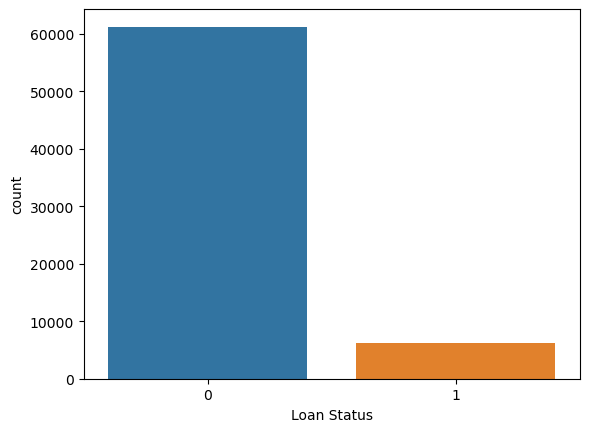

In [27]:
sns.countplot(df['Loan Status'])
plt.show()

- Target column 'Loan Status' has an uneven distribution of observations for each class
- Class label 0 has a very high number of observations (~ 91% of the total)
- Under such situations our classifier may get biased towards the majority class
- So, we need to apply over-sample/under-sample technique

## 3. Data preparation for model building: [ Score: 5 points ]

- Before segregating the target and independent features we need to deal with column 'Batch Enrolled'
- Entries in 'Batch Enrolled' contains string 'BAT' attached to each entry, need to be handled
- We remove string 'BAT' and convert the datatype into numerical
- Also we need to encode the other categorical features

In [28]:
df["Batch Enrolled"] = df["Batch Enrolled"].str.replace("BAT", "").astype('int64')

## Encoding:

- Since One Hot Encoding is the most commonly used technique for encoding categorical features
- However, in this case we avoid applying OHE, since we have categorical features with large number of classes.
- For example 'Loan title' has as many as 109 unique classes.
- In the process of cleaning,we don't accept categorical data. 
- All the data should be numeric.
- Machines understand numbers only and not text.

In [29]:
# List of all categorical features

cat_list =['Grade','Sub Grade','Employment Duration','Verification Status','Loan Title','Initial List Status','Application Type ']

- The features in cat_list are to be encoded as per their category as follows:

- Category of each Categorical feature:
    
    - 1. Nominal
        - Employment Duration
        - Verification Status
        - Loan Title
        
    - 2. Ordinal
        - Grade
        - Sub Grade
        
    - 3. Binary
        - Initial List Status
        - Application Type

In [30]:
# 1. Encoding Nominal Categorical variables - 'Employment Duration'(Frequency encoding)

df_ed = df['Employment Duration'].value_counts(normalize = True).to_dict()
df_ed

{'MORTGAGE': 0.538828691282629,
 'RENT': 0.3579740005632717,
 'OWN': 0.10319730815409929}

In [31]:
df['Employment Duration'] = df['Employment Duration'].map(df_ed)

In [32]:
# 2. Encoding Nominal Categorical variables - Verification Status(Frequency encoding) 

df_vs = df['Verification Status'].value_counts(normalize = True).to_dict()
df_vs

{'Source Verified': 0.48969064524257744,
 'Verified': 0.2679691089930777,
 'Not Verified': 0.2423402457643449}

In [33]:
df['Verification Status'] = df['Verification Status'].map(df_vs)

In [34]:
# 3. Encoding Nominal Categorical variables - Loan Title(Frequency encoding)

df_lt = df['Loan Title'].value_counts(normalize = True).to_dict()

In [35]:
df['Loan Title'] = df['Loan Title'].map(df_lt)

In [36]:
# 4. Encoding Ordinal Categorical variables - Grade

grade = {"A":1, "B":2, "C":3, "D":4, "E":5, "F":6, "G":7 }

df['Grade'] = df['Grade'].map(grade)

In [37]:
# 5. Encoding Ordinal Categorical variables - Sub Grade

subgrade = {"A1":1, "A2":2, "A3":3, "A4":4, "A5":5,
           "B1":6, "B2":7, "B3":8, "B4":9, "B5":10,
           "C1":11, "C2":12, "C3":13, "C4":14, "C5":15,
           "D1":16, "D2":17, "D3":18, "D4":19, "D5":20,
           "E1":21, "E2":22, "E3":23, "E4":24, "E5":25,
           "F1":26, "F2":27, "F3":28, "F4":29, "F5":30,
           "G1":31, "G2":32, "G3":33, "G4":34, "G5":35}


df['Sub Grade'] = df['Sub Grade'].map(subgrade)

In [38]:
# Label encoding the binary categorical columns

# Binary categorical data
cat_cols = ['Initial List Status','Application Type'] 

from sklearn.preprocessing import LabelEncoder

# instantiate labelencoder object
le = LabelEncoder()

# apply le on categorical feature columns
df[cat_cols] = df[cat_cols].apply(lambda col: le.fit_transform(col))

### Encoded as: 

- 'Initial List Status': 'w'=1, 'f'=0 
- 'Application Type': 'INDIVIDUAL'= 0, 'JOINT'= 1

### Segregate the target and independent features

In [39]:
X=df.drop('Loan Status',axis=1) 
y=df['Loan Status'] 
X.head()

,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit
0,10000,32236,12329.36286,59,2522922,11.135007,2,14,0.538829,176346.62670,0.242340,0.052532,16.284758,1,0,13,0,24246,74.932551,7,1,2929.646315,0.102055,2.498291,0.793724,0,0,49,31,311301,6619
1,3609,11940,12191.99692,59,1586599,12.237563,3,18,0.357974,39833.92100,0.489691,0.368217,15.412409,0,0,12,0,812,78.297186,13,0,772.769385,0.036181,2.377215,0.974821,0,0,109,53,182610,20885
2,28276,9311,21603.22455,59,2136391,12.545884,6,19,0.538829,91506.69105,0.489691,0.052532,28.137619,0,0,14,0,1843,2.073040,20,1,863.324396,18.778660,4.316277,1.020075,0,0,66,34,89801,26155
3,11170,6954,17877.15585,59,2428731,16.731201,3,13,0.538829,108286.57590,0.489691,0.368217,18.043730,1,0,7,0,13819,67.467951,12,1,288.173196,0.044131,0.107020,0.749971,0,0,39,40,9189,60214
4,16890,13226,13539.92667,59,5341619,15.008300,3,19,0.538829,44234.82545,0.489691,0.455479,17.209886,1,3,13,1,1544,85.250761,22,1,129.239553,19.306646,1294.818751,0.368953,0,0,18,430,126029,22579


### Handle the imbalanced data using oversampling or under sampling approach

- Here, we are balancing the imbalanced data using Oversampling approach
- We apply SMOTE(Synthetic Minority Oversampling Technique) of Oversampling approach

In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.85)     # We keep 85% of the class0 as our sampling_strategy
X_res,y_res = smote.fit_resample(X,y)     # We fit SMOTE to our original data and get resampled X_res,y_res 

In [41]:
X_res.shape

(113260, 31)

### Check the distribution of the resampled target class

In [42]:
pd.DataFrame(y_res).value_counts(normalize=True)*100

Loan Status
0              54.054388
1              45.945612
dtype: float64

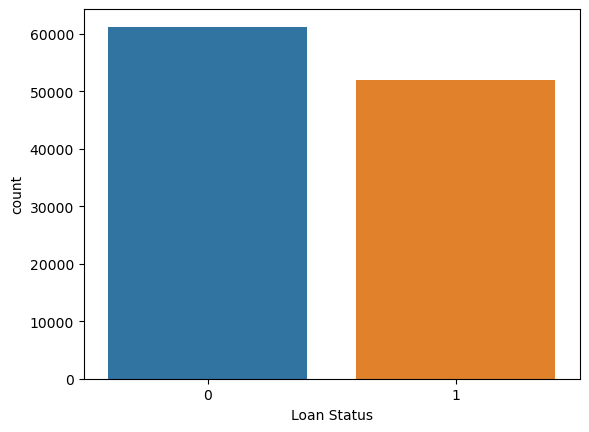

In [43]:
sns.countplot(y_res)
plt.show()

- We can observe, we have successfully oversampled the minority class, class1
- The distribution of the target class is balanced as class0:54%, class1:46%

### Split the data into train and test.

In [44]:
## Splitting the balanced data into train and test.

X_train, X_test, y_train, y_test = train_test_split(X_res,y_res, test_size=0.20, random_state=42)

print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(90608, 31) (22652, 31)
(90608,) (22652,)


## Model building using the Balanced data.

In [45]:
## Building a Decision Tree Classifier as a base model using balanced data.
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

## Prediction on original test data
dt_base = dt.predict(X_test)

## Computing Accuracy, Recall, and Classification Report for test data
print("Accuracy:",metrics.accuracy_score(dt_base,y_test))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(dt_base, y_test))
print(' ')
print("Recall:",metrics.recall_score(dt_base,y_test))
print(' ')
print("Classification Report:\n",metrics.classification_report(dt_base,y_test))

Accuracy: 0.8714020837012184
 
Confusion Matrix:
 [[10762  1278]
 [ 1635  8977]]
 
Recall: 0.8459291368262345
 
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88     12040
           1       0.88      0.85      0.86     10612

    accuracy                           0.87     22652
   macro avg       0.87      0.87      0.87     22652
weighted avg       0.87      0.87      0.87     22652



- The recall for both the classes(0 and 1) are equal to 0.89 and 0.84 which is a good value.
- Accuracy of the model is 87%

### Select the K best features using wrapper or embedded methods

- As Random Forest Classifier Model is taking very long time
- So here we are using Decision Tree Classifier model for selecting the K best features

### Using Decision Tree Classifier to build step forward feature selection technique(Wrapper method)

In [46]:
# Build Decision Tree Classifier model to use in feature selection
dt = DecisionTreeClassifier()

# Build step forward feature selection
sfs1 = sfs(dt, k_features=15, forward=True, cv=5)

# Perform SFFS
sfs1 = sfs1.fit(X_train, y_train)

In [47]:
sfs2=sfs1.get_metric_dict()

In [48]:
#Converting result of sfs1 to dataframe
sfs2 = pd.DataFrame.from_dict(sfs2)

In [49]:
sfs2

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
feature_idx,"(11,)","(10, 11)","(8, 10, 11)","(3, 8, 10, 11)","(3, 8, 10, 11, 26)","(3, 8, 10, 11, 25, 26)","(3, 8, 10, 11, 16, 25, 26)","(3, 8, 10, 11, 14, 16, 25, 26)","(3, 8, 10, 11, 14, 16, 20, 25, 26)","(3, 8, 10, 11, 13, 14, 16, 20, 25, 26)","(3, 6, 8, 10, 11, 13, 14, 16, 20, 25, 26)","(3, 4, 6, 8, 10, 11, 13, 14, 16, 20, 25, 26)","(3, 4, 6, 8, 10, 11, 13, 14, 16, 20, 25, 26, 29)","(3, 4, 6, 8, 10, 11, 13, 14, 16, 19, 20, 25, 2...","(1, 3, 4, 6, 8, 10, 11, 13, 14, 16, 19, 20, 25..."
cv_scores,"[0.7959938196667035, 0.8029466946253173, 0.802...","[0.8884229113784351, 0.891899348857742, 0.8917...","[0.9184968546518044, 0.9189934885774197, 0.921...","[0.918552036199095, 0.9189934885774197, 0.9224...","[0.918552036199095, 0.9189383070301291, 0.9223...","[0.918552036199095, 0.918827943935548, 0.92224...","[0.9181657653680609, 0.918552036199095, 0.9213...","[0.9170621344222492, 0.9178346760843175, 0.920...","[0.9161240481183093, 0.9177243129897362, 0.919...","[0.9153515064562411, 0.9157929588345657, 0.917...","[0.9099988963690542, 0.9099988963690542, 0.912...","[0.890023176249862, 0.8885332744730162, 0.8931...","[0.8766692418055402, 0.8784902328661296, 0.880...","[0.8747930691976603, 0.8776625096567707, 0.880...","[0.8773314203730272, 0.8781039620350954, 0.877..."
avg_score,0.80164,0.891665,0.920294,0.920647,0.920614,0.920515,0.920062,0.919312,0.918407,0.916773,0.911432,0.889943,0.877296,0.87766,0.876501
feature_names,"(Loan Title,)","(Verification Status, Loan Title)","(Employment Duration, Verification Status, Loa...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Grade, Employment Duration, Verificatio...","(Term, Batch Enrolled, Grade, Employment Durat...","(Term, Batch Enrolled, Grade, Employment Durat...","(Term, Batch Enrolled, Grade, Employment Durat...","(Funded Amount, Term, Batch Enrolled, Grade, E..."
ci_bound,0.003845,0.002227,0.002432,0.002664,0.002642,0.002682,0.002588,0.002685,0.002609,0.00254,0.002702,0.002191,0.002878,0.002632,0.002024
std_dev,0.002992,0.001733,0.001892,0.002072,0.002055,0.002087,0.002014,0.002089,0.00203,0.001976,0.002103,0.001705,0.002239,0.002048,0.001575
std_err,0.001496,0.000866,0.000946,0.001036,0.001028,0.001044,0.001007,0.001045,0.001015,0.000988,0.001051,0.000852,0.00112,0.001024,0.000787


In [50]:
# import required lbraries to plot the graph
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

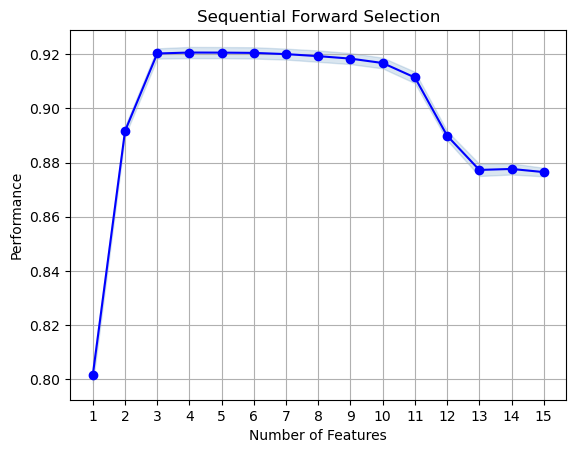

In [51]:
# For k=3 maximum accuracy of 92%.

fig = plot_sfs(sfs2)
plt.title('Sequential Forward Selection')
plt.grid()
plt.show()

In [52]:
# Best 15 features
columnList = list(X)
feat_cols = list(sfs1.k_feature_idx_)
print(feat_cols)

[1, 3, 4, 6, 8, 10, 11, 13, 14, 16, 19, 20, 25, 26, 29]


In [53]:
# Names of 15 best features

subsetColumnList = [columnList[i] for i in feat_cols] 
print(subsetColumnList)

['Funded Amount', 'Term', 'Batch Enrolled', 'Grade', 'Employment Duration', 'Verification Status', 'Loan Title', 'Delinquency - two years', 'Inquires - six months', 'Public Record', 'Total Accounts', 'Initial List Status', 'Collection 12 months Medical', 'Application Type', 'Total Current Balance']


In [54]:
X_train_new=pd.DataFrame(X_train[subsetColumnList])
X_test_new=pd.DataFrame(X_test[subsetColumnList])

In [55]:
X_train.head()

,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit
56229,16530,10009,20178.207300,59,5629144,15.625935,4,24,0.538829,64383.357950,0.242340,0.000326,33.583514,0,0,12,1,6382,70.445491,23,0,1620.838682,0.016393,1.445103,1.299561,0,0,58,6,85877,46352
90304,13529,12227,9139.453478,58,5714674,13.830989,3,13,0.357974,103928.075121,0.267969,0.385883,20.874349,0,0,10,0,24996,44.724597,10,0,2228.403652,0.017964,1.507748,1.142872,0,0,69,52,171328,28222
93028,17461,19975,21501.275874,59,1467036,13.242596,2,21,0.538829,89115.600112,0.489691,0.368217,31.558722,0,0,12,0,4989,47.422139,17,1,476.250755,0.031542,4.946346,0.484604,0,0,67,39,15146,10286
33168,32549,30495,16849.006410,58,3726927,5.880601,3,3,0.538829,38031.599020,0.489691,0.455479,20.604400,2,1,14,0,13249,6.066809,16,1,6630.932715,0.020865,9.276868,0.176705,0,0,45,12,161807,7754
27099,11541,7294,10677.376640,59,2522922,19.761515,1,13,0.538829,94287.841510,0.489691,0.455479,15.468562,0,0,12,0,920,32.375419,31,0,575.457239,0.027148,6.077388,0.782650,0,0,23,8,147143,2714


In [56]:
col_trans = ColumnTransformer([('ss',StandardScaler(), X_train_new.columns)])

## 5. Pipeline

In [57]:
# Building a pipeline
pipeline = Pipeline([ ('preprocessor',col_trans),('algo',DecisionTreeClassifier())])

In [58]:
col_trans.fit(X_train_new)

ColumnTransformer(transformers=[('ss', StandardScaler(),
                                 Index(['Funded Amount', 'Term', 'Batch Enrolled', 'Grade',
       'Employment Duration', 'Verification Status', 'Loan Title',
       'Delinquency - two years', 'Inquires - six months', 'Public Record',
       'Total Accounts', 'Initial List Status', 'Collection 12 months Medical',
       'Application Type', 'Total Current Balance'],
      dtype='object'))])

In [59]:
### Parameters to tune.
param_dt = [{'algo__criterion':['gini', 'entropy'],'algo__max_depth':(7,25)}]

In [60]:
# Create an instance of RandomizedSearchCV as model
random_cv = RandomizedSearchCV(pipeline,param_dt,cv=5,n_jobs=-1,verbose=1)

#learning
random_cv.fit(X_train_new,y_train)

# print best hyperparameters from shared set of parameters
print("Best Hyper Parameters:\n",random_cv.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Hyper Parameters:
 {'algo__max_depth': 7, 'algo__criterion': 'entropy'}


In [61]:
# Building a pipeline and passing the transformer and the classfier
# Building a pipeline

pipeline_dt = Pipeline([
    ('preprocessor',col_trans),
    ('algo',DecisionTreeClassifier(max_depth= 7, criterion= 'entropy',random_state=0))])

In [62]:
## Fitting the pipeline on the train data.
pipeline_dt.fit(X_train_new,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ss', StandardScaler(),
                                                  Index(['Funded Amount', 'Term', 'Batch Enrolled', 'Grade',
       'Employment Duration', 'Verification Status', 'Loan Title',
       'Delinquency - two years', 'Inquires - six months', 'Public Record',
       'Total Accounts', 'Initial List Status', 'Collection 12 months Medical',
       'Application Type', 'Total Current Balance'],
      dtype='object'))])),
                ('algo',
                 DecisionTreeClassifier(criterion='entropy', max_depth=7,
                                        random_state=0))])

In [63]:
## Prediction on test data
prediction_dt = pipeline_dt.predict(X_test_new)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction_dt,y_test))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction_dt, y_test))
print(' ')
print("Recall:",metrics.recall_score(prediction_dt,y_test))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction_dt,y_test))

Accuracy:
 0.8935634822532227
 
Confusion Matrix:
 [[12392  2406]
 [    5  7849]]
 
Recall: 0.9993633817163229
 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.91     14798
           1       0.77      1.00      0.87      7854

    accuracy                           0.89     22652
   macro avg       0.88      0.92      0.89     22652
weighted avg       0.92      0.89      0.90     22652



- The recall for both the classes(0 and 1) are equal to 0.84 and 1.0 which is a good value.
- Accuracy of the model is increased from 87% to 90% after tuning and setting optimum parameters and cv through pipeline.

### Using Random Forest Classifier to build step forward feature selection technique(Wrapper method)

In [64]:
# Build Random Forest Classifier model to use in feature selection

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

## Prediction on original test data
rf_base = rf.predict(X_test)

## Computing Accuracy, Recall, and Classification Report for test data
print("Accuracy:",metrics.accuracy_score(rf_base,y_test))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(rf_base, y_test))
print(' ')
print("Recall:",metrics.recall_score(rf_base,y_test))
print(' ')
print("Classification Report:\n",metrics.classification_report(rf_base,y_test))

Accuracy: 0.9335158043439873
 
Confusion Matrix:
 [[12392  1501]
 [    5  8754]]
 
Recall: 0.9994291585797466
 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94     13893
           1       0.85      1.00      0.92      8759

    accuracy                           0.93     22652
   macro avg       0.93      0.95      0.93     22652
weighted avg       0.94      0.93      0.93     22652



- The recall for both the classes(0 and 1) are equal to 0.89 and 1.00  which is a good value.
- (meaning of recall = 1.0 for class1 thereby that there are no false negatives).
- That is the imbalance in the distribution in 'Loan Status' has been perfectly resolved
- Accuracy of the model is 93%, which seems good

In [65]:
# Took 3.5 hours to run this code

# Build step forward feature selection
sfs1 = sfs(rf, k_features=15, forward=True, cv=5)

# Perform SFFS
sfs1 = sfs1.fit(X_train, y_train)

In [66]:
sfs2=sfs1.get_metric_dict()

In [67]:
#Converting result of sfs1 to dataframe

sfs2 = pd.DataFrame.from_dict(sfs2)

In [68]:
sfs2

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
feature_idx,"(11,)","(10, 11)","(8, 10, 11)","(3, 8, 10, 11)","(3, 8, 10, 11, 26)","(3, 8, 10, 11, 25, 26)","(3, 8, 10, 11, 14, 25, 26)","(3, 8, 10, 11, 14, 16, 25, 26)","(3, 8, 10, 11, 14, 16, 20, 25, 26)","(3, 8, 10, 11, 13, 14, 16, 20, 25, 26)","(3, 6, 8, 10, 11, 13, 14, 16, 20, 25, 26)","(3, 4, 6, 8, 10, 11, 13, 14, 16, 20, 25, 26)","(3, 4, 6, 8, 10, 11, 13, 14, 16, 20, 25, 26, 29)","(3, 4, 6, 8, 9, 10, 11, 13, 14, 16, 20, 25, 26...","(3, 4, 6, 8, 9, 10, 11, 13, 14, 16, 20, 25, 26..."
cv_scores,"[0.7959938196667035, 0.8029466946253173, 0.802...","[0.8884780929257257, 0.891899348857742, 0.8917...","[0.918552036199095, 0.9191038516720009, 0.9218...","[0.918552036199095, 0.9190486701247103, 0.9220...","[0.9186072177463857, 0.9189934885774197, 0.922...","[0.9187175808409668, 0.9181105838207704, 0.921...","[0.9180002207261891, 0.9175587683478644, 0.921...","[0.9174484052532833, 0.9172828606114115, 0.920...","[0.9158481403818564, 0.9168414082330869, 0.919...","[0.9144134201523011, 0.9149652356252069, 0.918...","[0.9127579737335835, 0.9114887981459, 0.914413...","[0.9064672773424567, 0.9061913696060038, 0.909...","[0.9240701909281537, 0.9252841849685465, 0.926...","[0.9309127027921863, 0.9311886105286392, 0.932...","[0.9304712504138616, 0.9321266968325792, 0.932..."
avg_score,0.80164,0.891643,0.920371,0.920515,0.920471,0.920239,0.919842,0.919014,0.918296,0.916542,0.913948,0.907436,0.925713,0.932048,0.932401
feature_names,"(Loan Title,)","(Verification Status, Loan Title)","(Employment Duration, Verification Status, Loa...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Employment Duration, Verification Statu...","(Term, Grade, Employment Duration, Verificatio...","(Term, Batch Enrolled, Grade, Employment Durat...","(Term, Batch Enrolled, Grade, Employment Durat...","(Term, Batch Enrolled, Grade, Employment Durat...","(Term, Batch Enrolled, Grade, Employment Durat..."
ci_bound,0.003845,0.002154,0.002466,0.002594,0.00263,0.002815,0.003028,0.002665,0.003028,0.003109,0.002492,0.001838,0.001932,0.001966,0.002357
std_dev,0.002992,0.001676,0.001919,0.002018,0.002046,0.00219,0.002356,0.002074,0.002356,0.002419,0.001939,0.00143,0.001503,0.001529,0.001834
std_err,0.001496,0.000838,0.000959,0.001009,0.001023,0.001095,0.001178,0.001037,0.001178,0.001209,0.000969,0.000715,0.000751,0.000765,0.000917


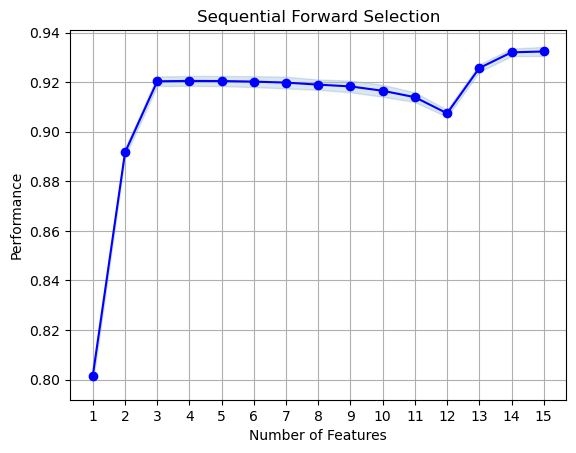

In [69]:
# Minimum k=14 giving the maximum accuracy of more than 93%.

fig = plot_sfs(sfs2)
plt.title('Sequential Forward Selection')
plt.grid()
plt.show()

In [70]:
# Best 15 feature

columnList = list(X)
feat_cols = list(sfs1.k_feature_idx_)
print(feat_cols)

[3, 4, 6, 8, 9, 10, 11, 13, 14, 16, 20, 25, 26, 29, 30]


In [71]:
# Names of 15 best features

subsetColumnList = [columnList[i] for i in feat_cols] 
print(subsetColumnList)

['Term', 'Batch Enrolled', 'Grade', 'Employment Duration', 'Home Ownership', 'Verification Status', 'Loan Title', 'Delinquency - two years', 'Inquires - six months', 'Public Record', 'Initial List Status', 'Collection 12 months Medical', 'Application Type', 'Total Current Balance', 'Total Revolving Credit Limit']


In [72]:
X_train_new=pd.DataFrame(X_train[subsetColumnList])
X_test_new=pd.DataFrame(X_test[subsetColumnList])

In [73]:
X_train_new.shape

(90608, 15)

In [74]:
col_trans = ColumnTransformer([('ss', StandardScaler(), X_train_new.columns)])

- Build a pipeline and put all the possible steps in the pipeline
- fit the pipeline on train data and get predictions on the test data

In [75]:
# Building a pipeline
pipeline = Pipeline([ ('preprocessor',col_trans),  # Scaling the data
    ('algo',RandomForestClassifier(random_state=0, n_jobs=-1))])

In [76]:
col_trans.fit(X_train_new)

ColumnTransformer(transformers=[('ss', StandardScaler(),
                                 Index(['Term', 'Batch Enrolled', 'Grade', 'Employment Duration',
       'Home Ownership', 'Verification Status', 'Loan Title',
       'Delinquency - two years', 'Inquires - six months', 'Public Record',
       'Initial List Status', 'Collection 12 months Medical',
       'Application Type', 'Total Current Balance',
       'Total Revolving Credit Limit'],
      dtype='object'))])

In [77]:
### Parameters to tune.
param_rf = [{'algo__n_estimators':[100, 200, 300, 500],
            'algo__max_depth':[5,7,9,11,13,15,19]}]

In [78]:
# Create an instance of GridSearchCV as model
grid_cv = GridSearchCV(pipeline,param_rf,cv=5,n_jobs=-1,verbose=1)

#learning
grid_cv.fit(X_train_new,y_train)

# print best hyperparameters from shared set of parameters
print("Best Hyper Parameters:\n",grid_cv.best_params_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Hyper Parameters:
 {'algo__max_depth': 19, 'algo__n_estimators': 500}


In [79]:
# Building a pipeline and passing the transformer and the classfier
# Building a pipeline

pipeline_rf = Pipeline([
    ('preprocessor',col_trans),
    ('algo',RandomForestClassifier(max_depth= 19, n_estimators= 500,random_state=0, n_jobs=-1))])

In [80]:
## Fitting the pipeline on the train data.
pipeline_rf.fit(X_train_new,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ss', StandardScaler(),
                                                  Index(['Term', 'Batch Enrolled', 'Grade', 'Employment Duration',
       'Home Ownership', 'Verification Status', 'Loan Title',
       'Delinquency - two years', 'Inquires - six months', 'Public Record',
       'Initial List Status', 'Collection 12 months Medical',
       'Application Type', 'Total Current Balance',
       'Total Revolving Credit Limit'],
      dtype='object'))])),
                ('algo',
                 RandomForestClassifier(max_depth=19, n_estimators=500,
                                        n_jobs=-1, random_state=0))])

In [81]:
## Prediction on test data
prediction_rf = pipeline_rf.predict(X_test_new)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction_rf,y_test))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction_rf, y_test))
print(' ')
print("Recall:",metrics.recall_score(prediction_rf,y_test))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction_rf,y_test))

Accuracy:
 0.926938018717994
 
Confusion Matrix:
 [[12396  1654]
 [    1  8601]]
 
Recall: 0.9998837479655894
 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.94     14050
           1       0.84      1.00      0.91      8602

    accuracy                           0.93     22652
   macro avg       0.92      0.94      0.92     22652
weighted avg       0.94      0.93      0.93     22652



In [ ]:
## 4. Model Building and evaluation: [ Score: 5 points ]

## Model building using the imbalanced data. Four Models considered:  
### LogisticRegression,Support Vector Classifier, Decision Tree Classifier and Random Forest Classifier models 

### Building base models using the Original Imbalanced data.

In [82]:
# Splitting the original dataset into train and test

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X,y, test_size=0.20, random_state=42)

print(X_train_base.shape,X_test_base.shape)
print(y_train_base.shape,y_test_base.shape)

(53970, 31) (13493, 31)
(53970,) (13493,)


In [83]:
# Building a Logistic Regression classification as a base model using original data.
lr = LogisticRegression(max_iter = 100)
lr.fit(X_train_base,y_train_base)

## Prediction on original test data
prediction_lr = lr.predict(X_test_base)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction_lr,y_test_base))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction_lr,y_test_base))
print(' ')
print("Recall:",metrics.recall_score(prediction_lr,y_test_base))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction_lr,y_test_base))

Accuracy:
 0.9097309716149115
 
Confusion Matrix:
 [[12275  1218]
 [    0     0]]
 
Recall: 0.0
 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     13493
           1       0.00      0.00      0.00         0

    accuracy                           0.91     13493
   macro avg       0.50      0.45      0.48     13493
weighted avg       1.00      0.91      0.95     13493



In [84]:
# Building Support Vector Classifier as a base model using original data.
svc = SVC()
svc.fit(X_train_base,y_train_base)

## Prediction on original test data
prediction_svc = svc.predict(X_test_base)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction_svc,y_test_base))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction_svc,y_test_base))
print(' ')
print("Recall:",metrics.recall_score(prediction_svc,y_test_base))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction_svc,y_test_base))

Accuracy:
 0.9097309716149115
 
Confusion Matrix:
 [[12275  1218]
 [    0     0]]
 
Recall: 0.0
 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     13493
           1       0.00      0.00      0.00         0

    accuracy                           0.91     13493
   macro avg       0.50      0.45      0.48     13493
weighted avg       1.00      0.91      0.95     13493



In [85]:

# Building a  Decision Tree Classifier as a base model using original data. 
# Decision tree lead in individual base model race with highest recall score of 86% ,

dt = DecisionTreeClassifier()
dt.fit(X_train_base,y_train_base)

## Prediction on original test data
prediction_dt = dt.predict(X_test_base)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction_dt,y_test_base))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction_dt,y_test_base))
print(' ')
print("Recall:",metrics.recall_score(prediction_dt,y_test_base))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction_dt,y_test_base))

Accuracy:
 0.8166456681242126
 
Confusion Matrix:
 [[10872  1071]
 [ 1403   147]]
 
Recall: 0.09483870967741935
 
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90     11943
           1       0.12      0.09      0.11      1550

    accuracy                           0.82     13493
   macro avg       0.50      0.50      0.50     13493
weighted avg       0.80      0.82      0.81     13493



In [86]:
## Building a simple Random Forest classifier as a base model using original data.

rf = RandomForestClassifier()
rf.fit(X_train_base,y_train_base)

## Prediction on original test data
prediction_rf = rf.predict(X_test_base)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction_rf,y_test_base))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction_rf,y_test_base))
print(' ')
print("Recall:",metrics.recall_score(prediction_rf,y_test_base))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction_rf,y_test_base))

Accuracy:
 0.9097309716149115
 
Confusion Matrix:
 [[12275  1218]
 [    0     0]]
 
Recall: 0.0
 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     13493
           1       0.00      0.00      0.00         0

    accuracy                           0.91     13493
   macro avg       0.50      0.45      0.48     13493
weighted avg       1.00      0.91      0.95     13493



- We can observe that we have a good accuracy score 91%,91%,82% and 91% for LogisticRegression,
- Support Vector Classifier, Decision Tree Classifier and random forest classifier models respectively.
- But in each of these models we have recall of 0.0 for minority class, which is too bad.
- It is to be noted that we have target which is highly imbalanced and accuracy will be biased.
- Precision, recall score, and f1-score is good for class 0 (majority class), 
- Where as precision, recall, and f1-score is zero for 1(minority class), due to the imbalance dataset.
- So, need to consider Recall score to evaluate the performance of the model. 
- Here we have recall score has 0. (too bad)
- To increase our model performance, we need to balance the data and need best features selection techniques.

## 6. Conclusions: [ Score: 1 point]

- Compare the evaluation metrics of the base model and the tuned model.
- Write your conclusion. 
- Mention the steps taken to improve the performance of the model.

## Performance of base imbalanced Models:
### ( Decision Tree Classifier and Random Forest Classifier Models)

In [87]:
# Building a  Decision Tree Classifier as a base model using original data.
# Poor recall score for class1

dt = DecisionTreeClassifier()
dt.fit(X_train_base,y_train_base)

## Prediction on original test data
prediction_dt = dt.predict(X_test_base)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction_dt,y_test_base))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction_dt,y_test_base))
print(' ')
print("Recall:",metrics.recall_score(prediction_dt,y_test_base))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction_dt,y_test_base))

Accuracy:
 0.8162009931075372
 
Confusion Matrix:
 [[10863  1068]
 [ 1412   150]]
 
Recall: 0.09603072983354674
 
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11931
           1       0.12      0.10      0.11      1562

    accuracy                           0.82     13493
   macro avg       0.50      0.50      0.50     13493
weighted avg       0.80      0.82      0.81     13493



In [88]:
# Building a simple Random Forest Classifier as a base model using original data.
# Recall is 0 for class1.

rf = RandomForestClassifier()
rf.fit(X_train_base,y_train_base)

## Prediction on original test data
prediction = rf.predict(X_test_base)

## Computing Accuracy,Confusion Matrix, Recall and Classification Report for test data
print("Accuracy:\n",metrics.accuracy_score(prediction,y_test_base))
print(' ')
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction,y_test_base))
print(' ')
print("Recall:",metrics.recall_score(prediction,y_test_base))
print(' ')
print("Classification Report:\n",metrics.classification_report(prediction,y_test_base))

Accuracy:
 0.9097309716149115
 
Confusion Matrix:
 [[12275  1218]
 [    0     0]]
 
Recall: 0.0
 
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     13493
           1       0.00      0.00      0.00         0

    accuracy                           0.91     13493
   macro avg       0.50      0.45      0.48     13493
weighted avg       1.00      0.91      0.95     13493



- We can observe that the performance of the base imbalanced Models is not good as compared to the tuned models

## To conclude:
- We can observe from the above results comparison of base model and the tuned model
- Significant increase in the Decision Tree model accuracy score(from 82% to 89%) and recall score(from 0 to 1).
- we can clearly see the impact of handling imbalanced data,feature selection and hyperparameter tuning, 
- we had a recall score of zero where we used original imbalanced data, after we handled imbalanced data 
- and selected best K features and tuned hyperparameters, we have a recall score greater than 80% for 
- Random forest classifier model and the Decision tree classifier model.
- First we balanced our imbalanced data using Oversampling approach.
- We had 31 features in the balanced dataset after removing the redundant features. 
- Out of 31 features we selected K=15 as the best features based on the feature importance.
- We tuned the hyperparameters for the RF Classifier using GridSearchCV with 5folds on the K best features.
- (the best combination of hyperparameters were 'max_depth': 19, 'n_estimators': 500}).
- We also tuned the hyperparameters for the Decision Tree Classifier using the RandomozedSearchCV with 5folds
- on the K best features.(the best combination of hyperparameters were 'max_depth': 7, 'criterion': 'entropy'}).
- Then we have built a pipeline, where when we pass the train data with best features, it will first scale the
- data, and then fit the RF and DT model with tuned parameters.
- From the both models that we have built we would prefer Random Forest algorithm over the 
- Decision Tree Classifier based on the algorithm performance on the data.
- In this notebook, I have tried on two models when comes to balancing the data, two methods of feature 
- selection, and have implemented two models for model selection and performed respective hyperparameter tuning. 
- Further, we can try out different data balancing approach, feature selection, and different models and
- hyperparameters to get best results.
- I applied  LogisticRegression,Support Vector Classifier, Decision Tree Classifier and Random Forest classifier
- for performance of base imbalanced Models.

### It is clear that Random Forest classifier model performs the best at every level,though it took lot of time to run the code.
### Feature Engineering like oversampling and hyperparameter tuning definitely has improved the performance 
### It is observed that when plotted for checking outliers in various features, these should have been removed for getting more improved results
### We applied oversampling technique to balance the data, could have applied undersampling technique.


## Thank you